In [80]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter, FuncAnimation
from safety_formation.controllers.cbf import CentralizedHOCBF, build_centralized_hocbf_constraints
from safety_formation.formation import Agent,Topology

## Static Obstacle Avoidance

<Axes: title={'center': 'Topology (Followers only)'}>

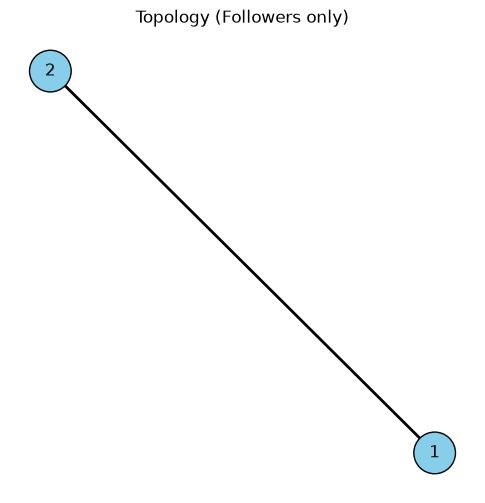

In [34]:
d_min = 0.5

# State format: [x, y, vx, vy]
x_agent0  = [0.0,  0.0,  0.0, 0.0]
x_obs0    = [5.0, -0.05, 0.0, 0.0]
x_target  = np.array([10.0, 0.0, 0.0, 0.0], dtype=float)

alpha_agent = 6.0
alpha_obs   = 0.0   # static obstacle

# --- Create agents using your Agent class ---
# f_target is not used in this experiment, so set it to zeros
agent = Agent(agent_id=1, x0=x_agent0, f_target=[0, 0, 0, 0], alpha=alpha_agent)
obs   = Agent(agent_id=2, x0=x_obs0,   f_target=[0, 0, 0, 0], alpha=alpha_obs)

all_agents = [agent, obs]

# Save initial states if you want history from t=0
for ag in all_agents:
    ag.save_history()

# --- Create topology ---
# Agent and obstacle are connected so CBF checks safety constraint between them
adj = np.array([
    [0, 1],
    [1, 0]
], dtype=float)

topology = Topology(num_agents=2, adjacency_matrix=adj)
topology.plot()

In [35]:
# --- Create CBF filter ---
cbf_filter = CentralizedHOCBF(k1_hocbf=10, k2_hocbf=3, safety_dis=d_min)

# --- History buffers ---
robot_history = []
u_hat_history = []
u_safe_history = []
h_history = []
dist_history = []

=== INITIAL HOCBF CONDITION ===
distance = 5.000249993750312
h0       = 24.7525
h_dot0   = 0.0
psi1_0   = 247.525

--- step 0, t = 0.00s ---
distance = 5.000250
h        = 24.752500
h_dot    = 0.000000
psi1     = 247.525000
h_ddot   = -60.000000
psi2     = 682.575000
u_nom    = [15. -0.]
u_safe   = [6. 0.]
max QP residual = 0.000000e+00

--- step 5, t = 0.50s ---
distance = 4.250294
h        = 17.815000
h_dot    = -25.500000
psi1     = 152.650000
h_ddot   = -33.000000
psi2     = 169.950000
u_nom    = [ 6.375 -0.   ]
u_safe   = [6. 0.]
max QP residual = 0.000000e+00

--- step 10, t = 1.00s ---
distance = 2.353248
h        = 5.287775
h_dot    = -15.633576
psi1     = 37.244175
h_ddot   = 44.603239
psi2     = 0.000000
u_nom    = [ 2.7215928  -0.05443026]
u_safe   = [-4.78319504  0.11134102]
max QP residual = -3.552714e-15

--- step 15, t = 1.50s ---
distance = 1.205238
h        = 1.202599
h_dot    = -3.552557
psi1     = 8.473428
h_ddot   = 10.105290
psi2     = 0.000000
u_nom    = [ 5.59702

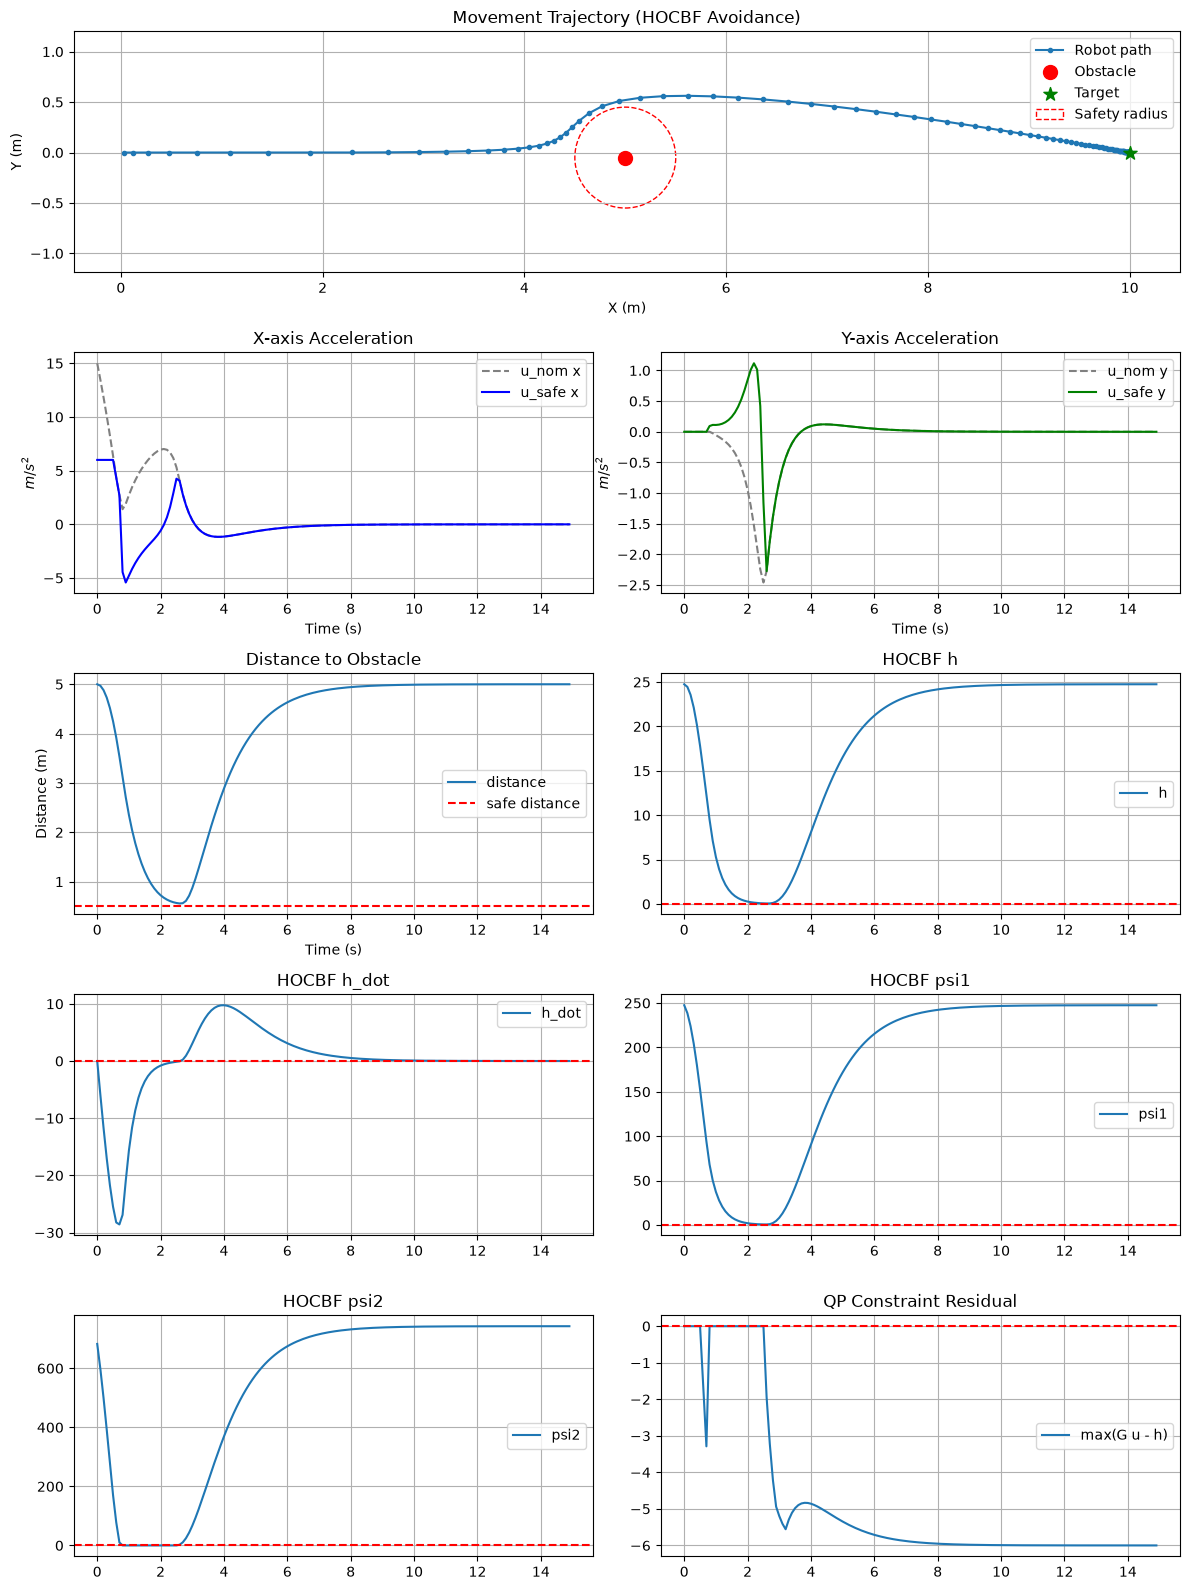

In [36]:
T = 15.0
dt = 0.1
steps = int(T / dt)

all_agents = [agent]

robot_history, u_hat_history, u_safe_history = [], [], []
dist_history = []
hocbf_h_history, hocbf_hdot_history = [], []
hocbf_psi1_history, hocbf_psi2_history = [], []
qp_residual_history = []

obstacles = [{
    "center": np.array(x_obs0[:2], dtype=float),
    "radius": 0.0
}]

p_obs = np.asarray(obstacles[0]["center"], dtype=float).reshape(-1)[:2]
r_obs = float(obstacles[0]["radius"])
d_obs_safe = r_obs + d_min

# Initial HOCBF condition
p_agent0 = np.asarray(agent.pos, dtype=float).reshape(-1)[:2]
v_agent0 = np.asarray(agent.vel, dtype=float).reshape(-1)[:2]

dp0 = p_agent0 - p_obs
h0 = np.dot(dp0, dp0) - d_obs_safe**2
h_dot0 = 2.0 * np.dot(dp0, v_agent0)
psi1_0 = h_dot0 + cbf_filter.k1_hocbf * h0

print("=== INITIAL HOCBF CONDITION ===")
print("distance =", np.linalg.norm(dp0))
print("h0       =", h0)
print("h_dot0   =", h_dot0)
print("psi1_0   =", psi1_0)
print("================================")

for k in range(steps):
    x_agent = agent.state.flatten()

    # Nominal controller
    u_hat = -1.5 * (x_agent[:2] - x_target[:2]) - 2.5 * x_agent[2:4]
    u_nom_all = np.array([u_hat], dtype=float)

    # HOCBF-QP
    u_safe_all = cbf_filter.compute_safe_control(
        all_agents=all_agents,
        topology=topology,
        u_nom=u_nom_all,
        obstacles=obstacles
    )

    u_apply = u_safe_all[0]

    # Rebuild constraints for diagnostics
    G, h_qp = build_centralized_hocbf_constraints(
        all_agents=all_agents,
        topology=topology,
        d_min=cbf_filter.d_min,
        k1_hocbf=cbf_filter.k1_hocbf,
        k2_hocbf=cbf_filter.k2_hocbf,
        obstacles=obstacles
    )

    u_vec = u_safe_all.flatten()
    residual = G @ u_vec - h_qp
    max_residual = np.max(residual)

    # HOCBF diagnostics before update
    p_agent = np.asarray(agent.pos, dtype=float).reshape(-1)[:2]
    v_agent = np.asarray(agent.vel, dtype=float).reshape(-1)[:2]

    dp = p_agent - p_obs
    dv = v_agent
    dist = np.linalg.norm(dp)

    h_hocbf = np.dot(dp, dp) - d_obs_safe**2
    h_dot = 2.0 * np.dot(dp, dv)
    psi1 = h_dot + cbf_filter.k1_hocbf * h_hocbf

    h_ddot = 2.0 * np.dot(dv, dv) + 2.0 * np.dot(dp, u_apply)

    psi2 = (
        h_ddot
        + (cbf_filter.k1_hocbf + cbf_filter.k2_hocbf) * h_dot
        + cbf_filter.k1_hocbf * cbf_filter.k2_hocbf * h_hocbf
    )

    if k % 5 == 0:
        print(f"\n--- step {k}, t = {k*dt:.2f}s ---")
        print(f"distance = {dist:.6f}")
        print(f"h        = {h_hocbf:.6f}")
        print(f"h_dot    = {h_dot:.6f}")
        print(f"psi1     = {psi1:.6f}")
        print(f"h_ddot   = {h_ddot:.6f}")
        print(f"psi2     = {psi2:.6f}")
        print(f"u_nom    = {u_hat}")
        print(f"u_safe   = {u_apply}")
        print(f"max QP residual = {max_residual:.6e}")

    dist_history.append(dist)
    hocbf_h_history.append(h_hocbf)
    hocbf_hdot_history.append(h_dot)
    hocbf_psi1_history.append(psi1)
    hocbf_psi2_history.append(psi2)
    qp_residual_history.append(max_residual)

    # Physics update
    agent.update_physics(u_apply, dt)

    # Safety check after update
    p_after = np.asarray(agent.pos, dtype=float).reshape(-1)[:2]
    dp_after = p_after - p_obs
    dist_after = np.linalg.norm(dp_after)
    h_after = np.dot(dp_after, dp_after) - d_obs_safe**2

    if h_after < 0:
        print(
            f"!!! SAFETY VIOLATION at t={(k+1)*dt:.2f}s: "
            f"distance={dist_after:.6f}, h={h_after:.6f}"
        )

    robot_history.append(agent.state.flatten().copy())
    u_hat_history.append(u_hat.copy())
    u_safe_history.append(u_apply.copy())

# Arrays
robot_history = np.array(robot_history)
u_hat_history = np.array(u_hat_history)
u_safe_history = np.array(u_safe_history)
dist_history = np.array(dist_history)

hocbf_h_history = np.array(hocbf_h_history)
hocbf_hdot_history = np.array(hocbf_hdot_history)
hocbf_psi1_history = np.array(hocbf_psi1_history)
hocbf_psi2_history = np.array(hocbf_psi2_history)
qp_residual_history = np.array(qp_residual_history)

time = np.arange(steps) * dt

# Plot
fig = plt.figure(figsize=(12, 16))

ax1 = plt.subplot(5, 1, 1)
ax1.plot(robot_history[:, 0], robot_history[:, 1], '-o', markersize=3, label='Robot path')
ax1.scatter(p_obs[0], p_obs[1], color='red', s=100, label='Obstacle', zorder=5)
ax1.scatter(x_target[0], x_target[1], color='green', s=100, marker='*', label='Target', zorder=5)
ax1.add_patch(plt.Circle(p_obs, d_obs_safe, color='red', fill=False, linestyle='--', label='Safety radius'))
ax1.set_title("Movement Trajectory (HOCBF Avoidance)")
ax1.set_xlabel("X (m)")
ax1.set_ylabel("Y (m)")
ax1.axis("equal")
ax1.grid(True)
ax1.legend()

ax2 = plt.subplot(5, 2, 3)
ax2.plot(time, u_hat_history[:, 0], '--', color='gray', label='u_nom x')
ax2.plot(time, u_safe_history[:, 0], color='blue', label='u_safe x')
ax2.set_title("X-axis Acceleration")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel(r"$m/s^2$")
ax2.grid(True)
ax2.legend()

ax3 = plt.subplot(5, 2, 4)
ax3.plot(time, u_hat_history[:, 1], '--', color='gray', label='u_nom y')
ax3.plot(time, u_safe_history[:, 1], color='green', label='u_safe y')
ax3.set_title("Y-axis Acceleration")
ax3.set_xlabel("Time (s)")
ax3.set_ylabel(r"$m/s^2$")
ax3.grid(True)
ax3.legend()

ax4 = plt.subplot(5, 2, 5)
ax4.plot(time, dist_history, label='distance')
ax4.axhline(d_obs_safe, linestyle='--', color='red', label='safe distance')
ax4.set_title("Distance to Obstacle")
ax4.set_xlabel("Time (s)")
ax4.set_ylabel("Distance (m)")
ax4.grid(True)
ax4.legend()

ax5 = plt.subplot(5, 2, 6)
ax5.plot(time, hocbf_h_history, label='h')
ax5.axhline(0.0, linestyle='--', color='red')
ax5.set_title("HOCBF h")
ax5.grid(True)
ax5.legend()

ax6 = plt.subplot(5, 2, 7)
ax6.plot(time, hocbf_hdot_history, label='h_dot')
ax6.axhline(0.0, linestyle='--', color='red')
ax6.set_title("HOCBF h_dot")
ax6.grid(True)
ax6.legend()

ax7 = plt.subplot(5, 2, 8)
ax7.plot(time, hocbf_psi1_history, label='psi1')
ax7.axhline(0.0, linestyle='--', color='red')
ax7.set_title("HOCBF psi1")
ax7.grid(True)
ax7.legend()

ax8 = plt.subplot(5, 2, 9)
ax8.plot(time, hocbf_psi2_history, label='psi2')
ax8.axhline(0.0, linestyle='--', color='red')
ax8.set_title("HOCBF psi2")
ax8.grid(True)
ax8.legend()

ax9 = plt.subplot(5, 2, 10)
ax9.plot(time, qp_residual_history, label='max(G u - h)')
ax9.axhline(0.0, linestyle='--', color='red')
ax9.set_title("QP Constraint Residual")
ax9.grid(True)
ax9.legend()

plt.tight_layout()
plt.show()

## Collision Avoidance for MAS

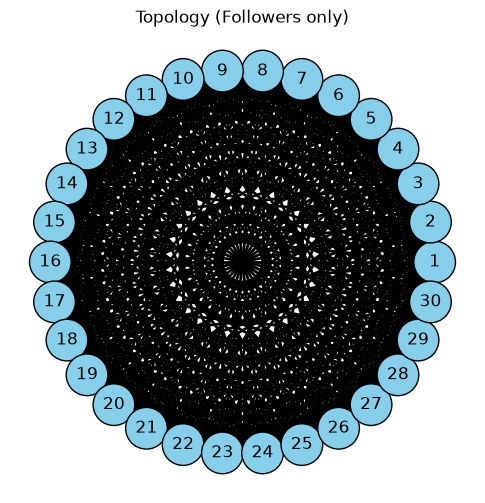

In [111]:
# --- Simulation Configuration ---
N = 30
R_circle = 150
dt = 0.1
T_max = 60.0
steps = int(T_max / dt)

k1_hocbf = 2
k2_hocbf = 1
d_min = 18.0
k1, k2 = 0.055, 0.4

alpha_val = 10.0
beta_val = 20.0

# --- Create agents using your Agent class ---
agents_list = []

for i in range(N):
    angle = 2 * np.pi * i / N

    # Initial state: [x, y, vx, vy]
    x0 = [
        R_circle * np.cos(angle),
        R_circle * np.sin(angle),
        0.0,
        0.0
    ]

    # Opposite-side target
    target_pos = -np.array(x0[0:2]) - 10

    # f_target is not used in this experiment
    ag = Agent(
        agent_id=i,
        x0=x0,
        f_target=[0.0, 0.0, 0.0, 0.0],
        alpha=alpha_val,
        beta=beta_val
    )

    # attach target for this experiment
    ag.target = target_pos.reshape(2,)
    agents_list.append(ag)

# --- Fully connected topology ---
adj_matrix = np.ones((N, N)) - np.eye(N)
topology = Topology(num_agents=N, adjacency_matrix=adj_matrix)

topology.plot()

# --- CBF filter ---
cbf_filter = CentralizedHOCBF(k1_hocbf=k1_hocbf, k2_hocbf=k2_hocbf, safety_dis=d_min)

# --- History ---
history = [[] for _ in range(N)]
u_nom_hist = [[] for _ in range(N)]
u_safe_hist = [[] for _ in range(N)]


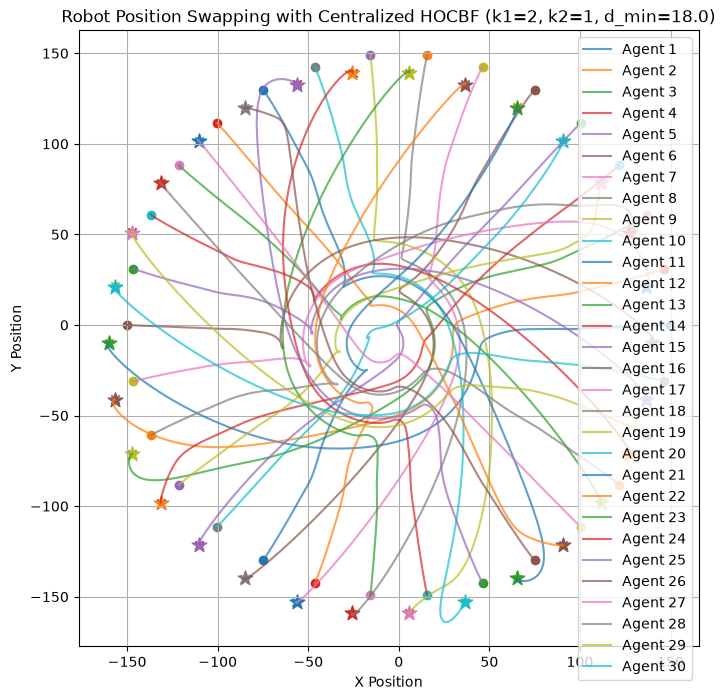

In [112]:
# --- Simulation Loop ---
for t in range(steps):
    # 1) Nominal PD control
    u_nom_all = []
    for ag in agents_list:
        pos = ag.pos.flatten()
        vel = ag.vel.flatten()

        u_i = -k1 * (pos - ag.target) - k2 * vel
        u_nom_all.append(u_i)

    u_nom_all = np.array(u_nom_all, dtype=float)

    # 2) Safe control through CBF-QP
    u_safe_all = cbf_filter.compute_safe_control(agents_list, topology, u_nom_all)

    # 3) Update agents
    for i, ag in enumerate(agents_list):
        ag.update_physics(u_safe_all[i], dt)

        history[i].append(ag.pos.flatten().copy())
        u_nom_hist[i].append(u_nom_all[i].copy())
        u_safe_hist[i].append(u_safe_all[i].copy())

# --- Convert history to arrays ---
history = [np.array(h) for h in history]
u_nom_hist = [np.array(h) for h in u_nom_hist]
u_safe_hist = [np.array(h) for h in u_safe_hist]

# --- Plot trajectories ---
plt.figure(figsize=(8, 8))
for i in range(N):
    traj = history[i]
    if len(traj) == 0:
        continue

    plt.plot(traj[:, 0], traj[:, 1], alpha=0.7, label=f'Agent {i+1}')
    plt.scatter(traj[0, 0], traj[0, 1], marker='o')
    plt.scatter(traj[-1, 0], traj[-1, 1], marker='x')
    plt.scatter(agents_list[i].target[0], agents_list[i].target[1], marker='*', s=120)

plt.title(f"Robot Position Swapping with Centralized HOCBF (k1={k1_hocbf}, k2={k2_hocbf}, d_min={d_min})")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

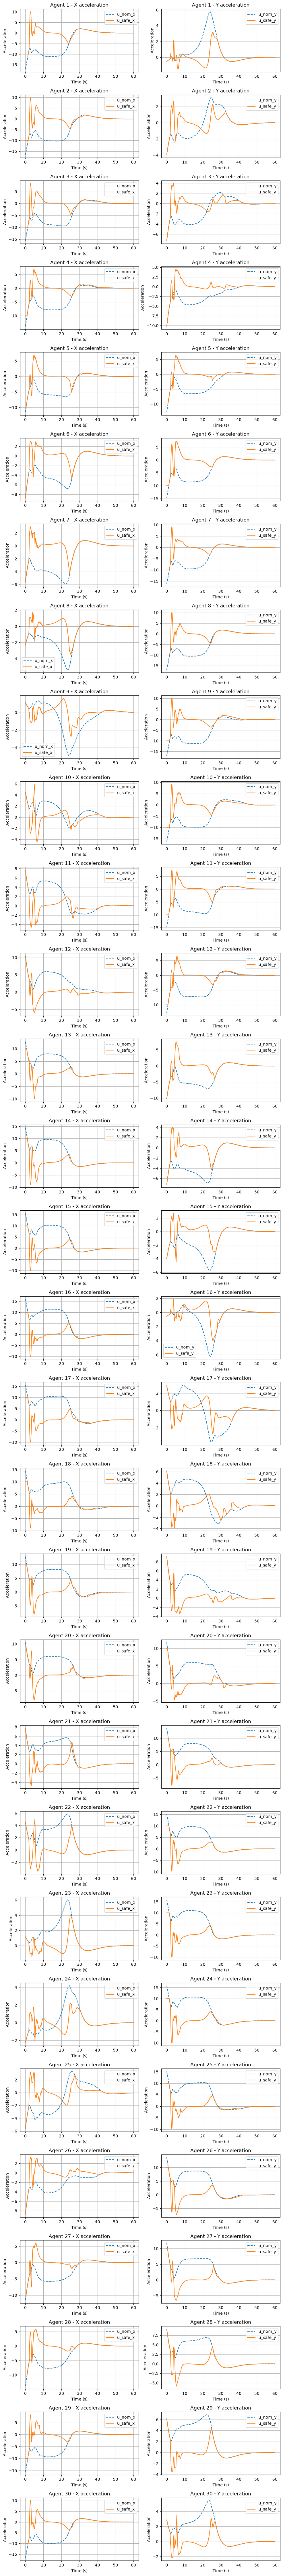

In [113]:
# --- Plot control inputs (for debugging) ---
time = np.arange(len(u_nom_hist[0])) * dt

fig, axes = plt.subplots(N, 2, figsize=(10, 3*N))

for i in range(N):
    u_nom = u_nom_hist[i]
    u_safe = u_safe_hist[i]

    # X control
    axes[i,0].plot(time, u_nom[:,0], '--', label='u_nom_x')
    axes[i,0].plot(time, u_safe[:,0], '-', label='u_safe_x')
    axes[i,0].set_title(f'Agent {i+1} - X acceleration')
    axes[i,0].set_xlabel('Time (s)')
    axes[i,0].set_ylabel('Acceleration')
    axes[i,0].grid(True)
    axes[i,0].legend()

    # Y control
    axes[i,1].plot(time, u_nom[:,1], '--', label='u_nom_y')
    axes[i,1].plot(time, u_safe[:,1], '-', label='u_safe_y')
    axes[i,1].set_title(f'Agent {i+1} - Y acceleration')
    axes[i,1].set_xlabel('Time (s)')
    axes[i,1].set_ylabel('Acceleration')
    axes[i,1].grid(True)
    axes[i,1].legend()

plt.tight_layout()
plt.show()

In [110]:
# --- Reinitialize agents ---
agents_list = []
history = [[] for _ in range(N)]

for i in range(N):
    angle = 2 * np.pi * i / N

    x0 = [
        R_circle * np.cos(angle),
        R_circle * np.sin(angle),
        0.0,
        0.0
    ]

    target = -np.array(x0[0:2]) - 10

    ag = Agent(i, x0, [0, 0, 0, 0], alpha=alpha_val, beta=beta_val)
    ag.target = target
    agents_list.append(ag)

# --- Animation figure ---
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-R_circle - 50, R_circle + 50)
ax.set_ylim(-R_circle - 50, R_circle + 50)
ax.set_aspect("equal")
ax.grid(True)
ax.set_title(f"{N} Robot Swapping - Centralized HOCBF (k1={k1_hocbf}, k2={k2_hocbf}, d_min={d_min})")

# plot targets
for ag in agents_list:
    ax.scatter(ag.target[0], ag.target[1], marker="x", color="red", s=100)

points = [ax.plot([], [], "o", ms=10)[0] for _ in range(N)]
trails = [ax.plot([], [], alpha=0.3, lw=1.5)[0] for _ in range(N)]

# safety circles
circles = []
for ag in agents_list:
    c = plt.Circle(
        (ag.pos[0, 0], ag.pos[1, 0]),
        d_min/2,
        fill=False,
        linestyle="--",
        alpha=0.5
    )
    ax.add_patch(c)
    circles.append(c)

info_text = ax.text(0.02, 0.95, "", transform=ax.transAxes)

# --- Update function ---
def update(frame):
    u_nom_all = []
    for ag in agents_list:
        pos = ag.pos.flatten()
        vel = ag.vel.flatten()

        u = -k1 * (pos - ag.target) - k2 * vel
        u = np.clip(u, -ag.alpha, ag.alpha)
        u_nom_all.append(u)

    u_nom_all = np.array(u_nom_all)

    # CBF filter
    u_safe_all = cbf_filter.compute_safe_control(agents_list, topology, u_nom_all)

    # physics update
    for i, ag in enumerate(agents_list):
        ag.update_physics(u_safe_all[i], dt)

        history[i].append(ag.pos.flatten().copy())
        traj = np.array(history[i])

        x = ag.pos[0, 0]
        y = ag.pos[1, 0]

        points[i].set_data([x], [y])
        trails[i].set_data(traj[:, 0], traj[:, 1])
        circles[i].center = (x, y)

    info_text.set_text(f"Time: {frame * dt:.1f}s")

    return points + trails + circles + [info_text]

# --- Render video ---
total_frames = int(T_max / dt)
ani = FuncAnimation(fig, update, frames=total_frames, blit=True)

writer = FFMpegWriter(fps=int(1 / dt), bitrate=2000)
ani.save("../media/centralized_hocbf_validation.mp4", writer=writer)

plt.close(fig)

print("Video saved: media/centralized_hocbf_validation.mp4")

Video saved: media/centralized_hocbf_validation.mp4
